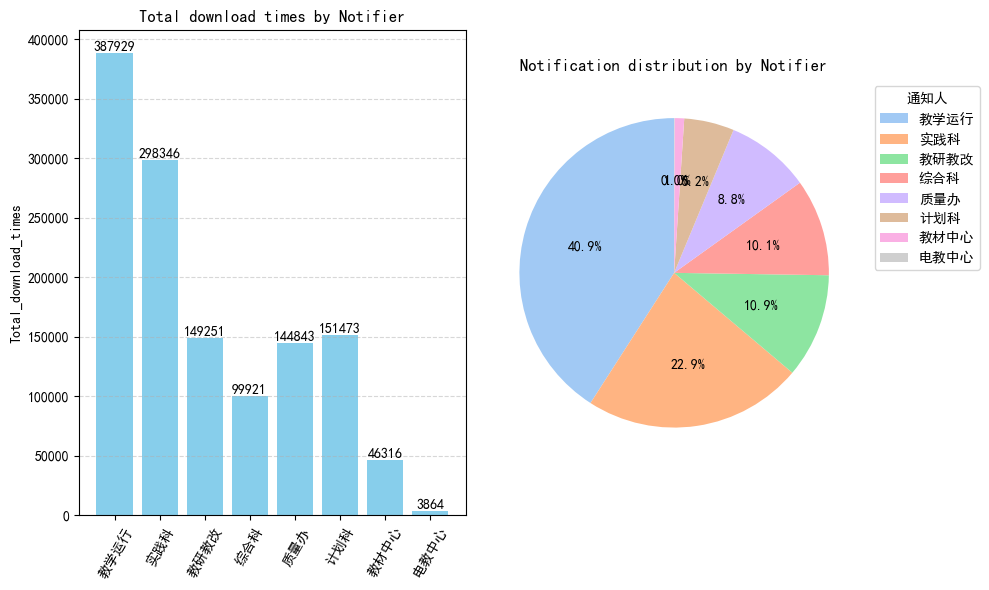

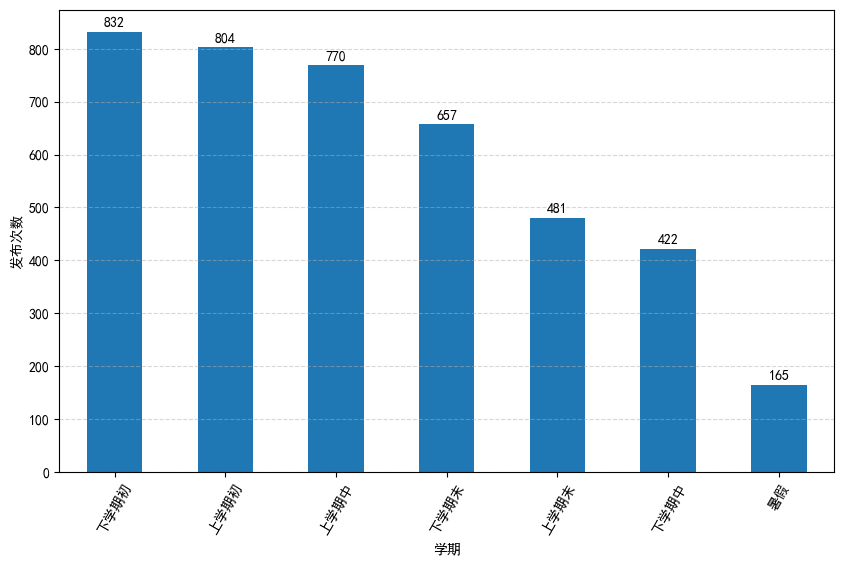

C:\Users\lxh\AppData\Local\Temp\ipykernel_41524\3261286174.py:98: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x="Length", y="Total_download_times", palette="bright")


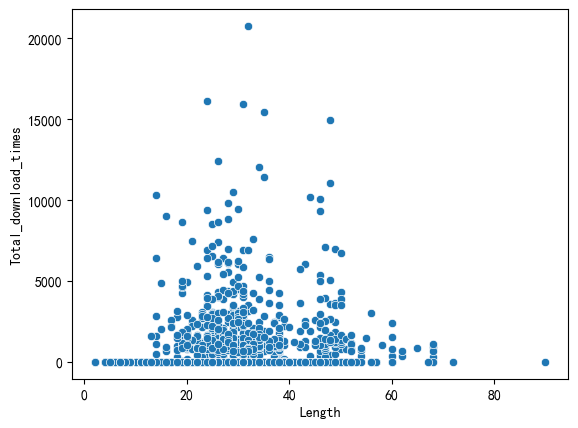

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams  # 设置中文字体

rcParams["font.sans-serif"] = ["SimHei"]  # 设置中文字体为SimHei

with open("nifu.csv", "r", encoding="utf-8") as f:  # 读取文件内容
    data = f.read()

Notifier = re.findall(r"来源:(.+)\n", data)  # 获取通知来源
date = re.findall(r"发布时间：(\d+-\d+-\d+)", data)  # 获取发布时间
title = re.findall(r"来源:.+\n(.+)\n", data)  # 获取通知标题
lenth = [len(i) for i in title]  # 获取标题长度
url = re.findall(r"详情链接:(.+)\n", data)  # 获取通知链接
blocks = re.split(r"--------------第\d+条--------------", data)
download_times = [re.findall(r"下载次数:(\d+)", block) for block in blocks]
downloadlist = []
for times in download_times:
    downloadlist.append(
        {
            "Download_times": times if times else [],
            "Total_download_times": sum(int(c) for c in times),
        }
    )
temp_df = pd.DataFrame(downloadlist)
df = pd.DataFrame(
    {"Title": title, "Length": lenth, "Date": date, "Notifier": Notifier, "URL": url}
)
df = pd.merge(df, temp_df, left_index=True, right_index=True)
df.to_csv("通知.csv", sep="|", index=False)

# 「通知人」都有谁？ 统计所有出现过的「通知人」，并计算他们各自发布的通知数量占总数的比例。附件下载次数与通知人的关系？
notice = pd.DataFrame(
    {"Notification count": df["Notifier"].value_counts().values},
    index=df["Notifier"].value_counts().index,
)
notice["Proportion"] = notice["Notification count"] / (
    notice["Notification count"].sum()
)
notice = pd.merge(
    notice, df.groupby("Notifier")["Total_download_times"].sum(), on="Notifier"
)
notice["Average download times"] = (
    notice["Total_download_times"] / notice["Notification count"]
).round(2)
plt.figure(figsize=(10, 6))
f1 = plt.subplot(1, 2, 1)
f1.bar(x=notice.index, height=notice["Total_download_times"], color="skyblue")
for index, value in enumerate(notice["Total_download_times"]):
    plt.text(index, value, str(value), ha="center", va="bottom")
plt.title("Total download times by Notifier")
plt.ylabel("Total_download_times")
plt.grid(axis="y", alpha=0.5, linestyle="--")
plt.xticks(rotation=60)

f2 = plt.subplot(1, 2, 2)
f2.pie(
    notice["Notification count"],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel"),
)
plt.legend(
    labels=notice.index, title="通知人", loc="upper left", bbox_to_anchor=(1, 0, 0.5, 1)
)
plt.title("Notification distribution by Notifier")
plt.tight_layout()
plt.show()
# 统计「发布时间」通知发布的高峰期？ 统计每天发布的通知数量，分析一下，通常在学期的哪个时间段，通知会变得特别密集？

df["Date"] = pd.to_datetime(df["Date"])
day_counts = (
    df["Date"].value_counts().sort_index(ascending=False).to_frame().reset_index()
)
day_counts["学期时段"] = pd.cut(
    day_counts["Date"].dt.month,
    bins=[0, 2, 4, 5, 7, 8, 10, 12],
    labels=[
        "上学期末",
        "下学期初",
        "下学期中",
        "下学期末",
        "暑假",
        "上学期初",
        "上学期中",
    ],
)
ax=day_counts.groupby("学期时段")["count"].sum().sort_values(ascending=False).plot(kind='bar',xlabel='学期',ylabel='发布次数',figsize=(10,6))
for container in ax.containers:
            ax.bar_label(container, label_type="edge", fmt="%d", padding=2)
plt.grid(axis="y", alpha=0.5, linestyle="--")
plt.xticks(rotation=60)            
plt.show()

# 自由探索，附件下载次数与通知标题长度的关系？是否存在某种趋势或模式？
sns.scatterplot(data=df, x="Length", y="Total_download_times", palette="bright")
plt.show()